# 3eme Approche

## Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r, norm, triang

## A. Contexte

On cherche la **hauteur de digue** $h_d$ qui **minimise le coût moyen annuel** $C_{c,moy}$.

### 1) Modèle hydraulique (Eq. (1)–(2))
On simule la surverse annuelle
$
S = Z_v + H - h_d - Z_b
$
avec la formule :

$H=\left(\frac{Q}{K_s \, B \,\sqrt{(Z_m-Z_v)/L}}\right)^{3/5}$

Les variables aléatoires sont $Q, K_s, Z_m, Z_v$, et $L,B,Z_b$ sont déterministes.


### 2) Modèle économique (Eq. (3)–(6))
- Nous choississons **$T = 100$ ans**

- Coût de digue sur $T$ ans :$C_t(T)=C_i(h_d)+T\,C_m(h_d),\quad\text{avec}\quad C_m(h_d)=0.01\,C_i(h_d).$
- Dommages sur **une année** :
$
C_d = C_s(S) + C_g(S,h_d),
\quad\text{où}\quad C_g(S,h_d)=\alpha(S)\,C_i(h_d).
$
($\alpha(S)$ est un pourcentage donné par le tableau 4.)

- Coût complet sur $T$ ans :
$
C_c(T)=C_t(T)+\sum_{j=1}^{T} C_{d,j}(S_j,h_d).
$

- Coût moyen annuel à minimiser :
$
C_{c,\text{moy}}=\frac{C_c(T)}{T}
= \frac{C_i(h_d)}{T} + C_m(h_d) + \mathbb{E}[C_d(S,h_d)].
$

## B. Déclaration des constantes, variables aléatoires et de la grillle de cout $C_i$

In [26]:
rng = np.random.default_rng(123)

T = 100        
N = 200_000    # taille de notre Monte-Carlo 

# Variables déterministes (tableau 3)
L = 5000.0     # m
B = 300.0      # m
Zb = 55.5      # m NGF

# Variables aléatoires (tableau 2)
Q_mode, Q_scale = 1013.0, 558.0
Q_dist = gumbel_r(loc=Q_mode, scale=Q_scale)

Ks_mu, Ks_sigma = 30.0, 7.5
Ks_dist = norm(loc=Ks_mu, scale=Ks_sigma)

Zv_mean, Zm_mean = 50.0, 55.0
tri_half_range = 1.0
Zv_dist = triang(c=0.5, loc=Zv_mean - tri_half_range, scale=2 * tri_half_range)
Zm_dist = triang(c=0.5, loc=Zm_mean - tri_half_range, scale=2 * tri_half_range)


# On encode directement la colonne "Coût d’investissement Ci (en k€)"
grid_hd = pd.DataFrame({
    "hd_m":  [0.0, 0.1, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
    "Ci_kE": [0,   100, 225, 1034, 4750, 11023, 16971, 21692, 26509, 31408, 36377, 41409, 46498]
})
grid_hd["Ci_EUR"] = grid_hd["Ci_kE"] * 1_000.0               # k€ -> €
grid_hd["Cm_EUR_per_year"] = 0.01 * grid_hd["Ci_EUR"]        # 1% de Ci par an

### Vérifications empirique 

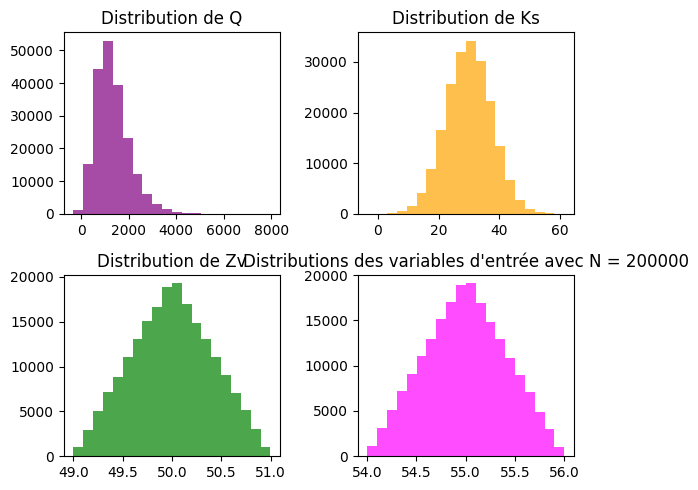

In [27]:
Q_samples  = Q_dist.rvs(size=N, random_state=rng)
Ks_samples = Ks_dist.rvs(size=N, random_state=rng)
Zv_samples = Zv_dist.rvs(size=N, random_state=rng)
Zm_samples = Zm_dist.rvs(size=N, random_state=rng)

# plot ces 4 variables pour voir si leur distribution correspond à ce qu'on attend
fig, axs = plt.subplots(2, 2, figsize=(6, 5))
axs[0, 0].hist(Q_samples, bins=20, color='purple', alpha=0.7)
axs[0, 0].set_title(f'Distribution de Q')
axs[0, 1].hist(Ks_samples, bins=20, color='orange', alpha=0.7)
axs[0, 1].set_title('Distribution de Ks')
axs[1, 0].hist(Zv_samples, bins=20, color='green', alpha=0.7)
axs[1, 0].set_title('Distribution de Zv')
axs[1, 1].hist(Zm_samples, bins=20, color='magenta', alpha=0.7)
axs[1, 1].set_title('Distribution de Zm')
plt.tight_layout()
plt.title(f'Distributions des variables d\'entrée avec N = {N}')
plt.show()

## C) Notre strategie Monte-Carlo pour $\mathbb{E}[C_d]$
Pour chaque $h_d$ du tab 5:
1. Tirer $N$ réalisations de $Q,K_s,Z_m,Z_v$.
2. Calculer $H$ puis $S$.
3. Convertir chaque $S$ en $C_s(S)$ et $\alpha(S)$ (tableau 4), donc $C_d$.
4. Estimer $\mathbb{E}[C_d]\approx \frac1N\sum_{i=1}^N C_d^{(i)}$.
5. Calculer $C_{c,\text{moy}}(h_d)=\frac{C_i}{T}+0.01\,C_i+\mathbb{E}[C_d]$.
6. Choisir le $h_d$ minimisant $C_{c,\text{moy}}$.

In [28]:
results = []

liste_hd = grid_hd["hd_m"].values

for _, row in grid_hd.iterrows():
    hd = float(row["hd_m"])
    Ci = float(row["Ci_EUR"])
    Cm = float(row["Cm_EUR_per_year"])

    # tirage pour le MC
    Q  = Q_dist.rvs(size=N, random_state=rng)
    Ks = Ks_dist.rvs(size=N, random_state=rng)
    Zv = Zv_dist.rvs(size=N, random_state=rng)
    Zm = Zm_dist.rvs(size=N, random_state=rng)

    # Sécurité numérique 
    Ks = np.maximum(Ks, 1e-12)
    slope = (Zm - Zv) / L
    slope = np.maximum(slope, 1e-12)

    # Modèle hydraulique : calcul de S
    H = (Q / (Ks * B * np.sqrt(slope))) ** (3.0 / 5.0)
    S = Zv + H - hd - Zb

    # CALCUL DES COÛTS DE DÉFAILLANCE Cd
    Cs = np.zeros(N, dtype=float)       # en €
    alpha = np.zeros(N, dtype=float)    # fraction (0.1 = 10%)

    # S <= -0.1 : Cs=0, alpha=0%
    mask = (S <= -0.1)
    Cs[mask] = 0.0
    alpha[mask] = 0.0

    # -0.1 < S <= 0 : Cs=0, alpha=10%
    mask = (S > -0.1) & (S <= 0.0)
    Cs[mask] = 0.0
    alpha[mask] = 0.10

    # 0 < S <= 0.5 : Cs=150 M€, alpha=50%
    mask = (S > 0.0) & (S <= 0.5)
    Cs[mask] = 150.0e6
    alpha[mask] = 0.50

    # 0.5 < S <= 1 : Cs=1500 M€, alpha=100%
    mask = (S > 0.5) & (S <= 1.0)
    Cs[mask] = 1500.0e6
    alpha[mask] = 1.00

    # 1 < S <= 1.5 : Cs=2000 M€, alpha=100%
    mask = (S > 1.0) & (S <= 1.5)
    Cs[mask] = 2000.0e6
    alpha[mask] = 1.00

    # S > 1.5 : Cs=2000 M€, alpha=100%
    mask = (S > 1.5)
    Cs[mask] = 2000.0e6
    alpha[mask] = 1.00

    Cg = alpha * Ci
    Cd = Cs + Cg

    # ----------------------------
    # (D) Agrégation : E[Cd] puis Cc_moy
    # ----------------------------
    E_Cd = float(Cd.mean())
    Cc_moy = (Ci / T) + Cm + E_Cd # en €

    results.append({
        "hd_m": hd,
        "Ci_EUR": Ci,
        "Cm_EUR_per_year": Cm,
        "E_Cd_EUR_per_year": E_Cd,
        "Cc_moy_EUR_per_year": Cc_moy
    })

# DataFrame final + tri
res_df = pd.DataFrame(results)
res_df_sorted = res_df.sort_values("Cc_moy_EUR_per_year").reset_index(drop=True)

print("Top 5 (meilleurs hd) selon Cc_moy :")
print(res_df_sorted.head(5))

best = res_df_sorted.iloc[0]
print("\n===> Hauteur optimale (éco) :")
print(f"hd* = {best['hd_m']} m")
print(f"Cc_moy(hd*) = {best['Cc_moy_EUR_per_year']:.3e} € / an")

Top 5 (meilleurs hd) selon Cc_moy :
   hd_m      Ci_EUR  Cm_EUR_per_year  E_Cd_EUR_per_year  Cc_moy_EUR_per_year
0   6.0  26509000.0         265090.0        211048.5350          741228.5350
1   7.0  31408000.0         314080.0        187983.7600          816143.7600
2   5.0  21692000.0         216920.0        387479.3980          821319.3980
3   4.0  16971000.0         169710.0        515845.2205          855265.2205
4   8.0  36377000.0         363770.0        224883.4285          952423.4285

===> Hauteur optimale (éco) :
hd* = 6.0 m
Cc_moy(hd*) = 7.412e+05 € / an


/var/folders/2b/txz191yj65l8dvw4jln17n680000gn/T/ipykernel_4780/3552934469.py:22: RuntimeWarning: invalid value encountered in power
  H = (Q / (Ks * B * np.sqrt(slope))) ** (3.0 / 5.0)


## Plot de l'évolution de $C_{c,moy}$ en fonction de $h_d$

,h_d (m),C_i (M€),C_m (M€/an),E[C_d] (M€/an),"C_c,moy (M€/an)"
8,6.0,26.509,0.26509,0.211049,0.741229
9,7.0,31.408,0.31408,0.187984,0.816144
7,5.0,21.692,0.21692,0.387479,0.821319
6,4.0,16.971,0.16971,0.515845,0.855265
10,8.0,36.377,0.36377,0.224883,0.952423
11,9.0,41.409,0.41409,0.164187,0.992367
12,10.0,46.498,0.46498,0.154354,1.084314
5,3.0,11.023,0.11023,0.911851,1.132311
4,2.0,4.750,0.04750,1.619966,1.714966
3,1.0,1.034,0.01034,4.119507,4.140187


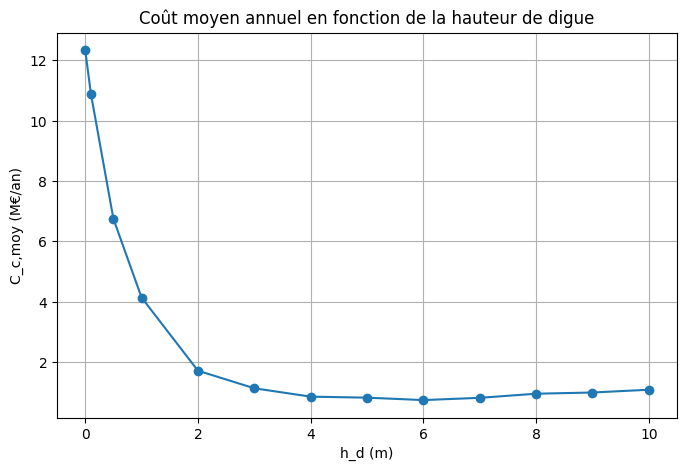

In [ ]:
# Tableau en M€/an
resultscopy = res_df.copy()
for col in ["Ci_EUR", "Cm_EUR_per_year", "E_Cd_EUR_per_year", "Cc_moy_EUR_per_year"]:
    resultscopy[col] = resultscopy[col] / 1e6  # € -> M€

resultscopy = resultscopy.rename(columns={
    "hd_m": "h_d (m)",
    "Ci_EUR": "C_i (M€)",
    "Cm_EUR_per_year": "C_m (M€/an)",
    "E_Cd_EUR_per_year": "E[C_d] (M€/an)",
    "Cc_moy_EUR_per_year": "C_c,moy (M€/an)"
})

display(resultscopy.sort_values("C_c,moy (M€/an)"))


plot_df = res_df.sort_values("hd_m")

plt.figure(figsize=(8, 5))
plt.plot(plot_df["hd_m"], plot_df["Cc_moy_EUR_per_year"] / 1e6, marker="o")
plt.xlabel("h_d (m)")
plt.ylabel("C_c,moy (M€/an)")
plt.title("Coût moyen annuel en fonction de la hauteur de digue")
plt.grid(True)
plt.show()